In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import *
from sklearn.model_selection import *
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import *
from sklearn.pipeline import Pipeline
from recurrence_data import load_recurrence_data



In [2]:
recurrence_data = load_recurrence_data()
data = recurrence_data["data"]

X = data.drop(columns=["recurrence_status", "poiseid"])
y = data["recurrence_status"]
groups = data["poiseid"]


# Whole Dataset

In [3]:
# scaler = MinMaxScaler()
# X_scaled = scaler.fit_transform(X)

## Logistic Regression

LR Model Cross-validation average score: 0.7108333333333333
Classes: [0 1]
y value counts:
 recurrence_status
0    68
1    28
Name: count, dtype: int64
y_train value counts:
 recurrence_status
0    54
1    22
Name: count, dtype: int64
y_test value counts:
 recurrence_status
0    14
1     6
Name: count, dtype: int64
Accuracy: 0.7
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC-AUC Score: 0.44047619047619047
Confusion Matrix:
[[14  0]
 [ 6  0]]


c:\Users\sp2sh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


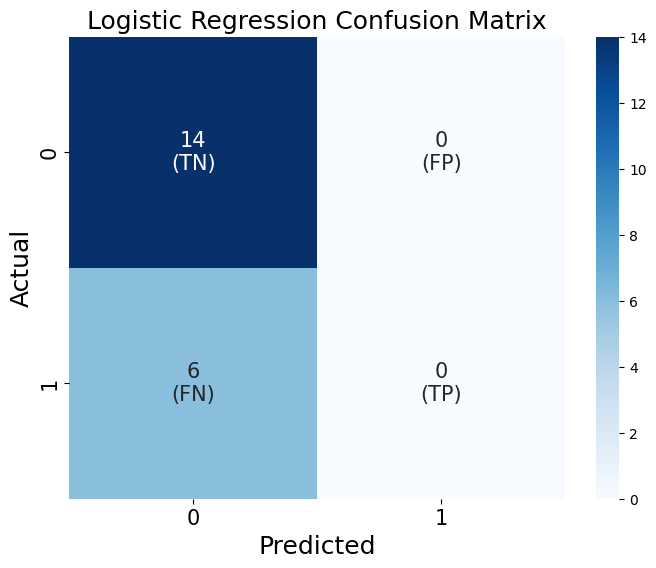

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=42, stratify=y)

LR_Model = Pipeline([
    ('scaler', MinMaxScaler()),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear'))
])

LR_cross_scores = cross_val_score(LR_Model, X_train, y_train, cv=5)
print(f'LR Model Cross-validation average score: {LR_cross_scores.mean()}')

# Train the model
LR_Model.fit(X_train, y_train)

print("Classes:", LR_Model.named_steps['classifier'].classes_)
print("y value counts:\n", y.value_counts())
print("y_train value counts:\n", y_train.value_counts())
print("y_test value counts:\n", y_test.value_counts())

# Predict on the test set
y_pred = LR_Model.predict(X_test)
y_pred_proba = LR_Model.predict_proba(X_test)[:, 1]

# Evaluation metrics
LR_accuracy = accuracy_score(y_test, y_pred)
LR_precision = precision_score(y_test, y_pred)
LR_recall = recall_score(y_test, y_pred)
LR_f1 = f1_score(y_test, y_pred)
LR_roc_auc = roc_auc_score(y_test, y_pred_proba)
LR_conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {LR_accuracy}')
print(f'Precision: {LR_precision}')
print(f'Recall: {LR_recall}')
print(f'F1 Score: {LR_f1}')
print(f'ROC-AUC Score: {LR_roc_auc}')
print(f'Confusion Matrix:\n{LR_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{LR_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(LR_conf_matrix.shape[1])] 
                              for i in range(LR_conf_matrix.shape[0])])

value, counts = np.unique(y_test, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(LR_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Logistic Regression Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

## Random Forest

RF Model Cross-validation average score: 0.7241666666666667


c:\Users\sp2sh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.65
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC-AUC Score: 0.5439560439560439
Confusion Matrix:
[[13  0]
 [ 7  0]]


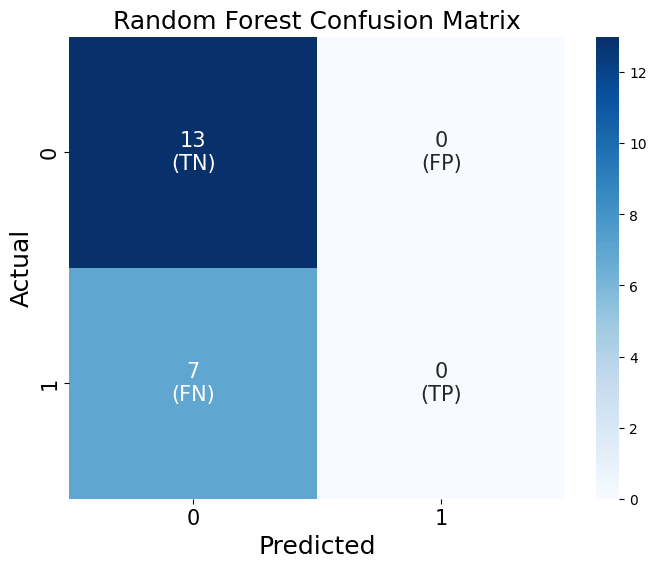

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

RF_Model = Pipeline([
    ('scaler', MinMaxScaler()),
    ('classifier', RandomForestClassifier())
])

RF_cross_scores = cross_val_score(RF_Model, X_train, y_train, cv=5)
print(f'RF Model Cross-validation average score: {RF_cross_scores.mean()}')

# Train the model
RF_Model.fit(X_train, y_train)

# Predict on the test set
y_pred = RF_Model.predict(X_test)
y_pred_proba = RF_Model.predict_proba(X_test)[:, 1]

# Evaluation metrics
RF_accuracy = accuracy_score(y_test, y_pred)
RF_precision = precision_score(y_test, y_pred)
RF_recall = recall_score(y_test, y_pred)
RF_f1 = f1_score(y_test, y_pred)
RF_roc_auc = roc_auc_score(y_test, y_pred_proba)
RF_conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {RF_accuracy}')
print(f'Precision: {RF_precision}')
print(f'Recall: {RF_recall}')
print(f'F1 Score: {RF_f1}')
print(f'ROC-AUC Score: {RF_roc_auc}')
print(f'Confusion Matrix:\n{RF_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{RF_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(RF_conf_matrix.shape[1])] 
                              for i in range(RF_conf_matrix.shape[0])])

value, counts = np.unique(y_test, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(RF_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Random Forest Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

## Naive Bayes

NB Model Cross-validation average score: 0.7241666666666667
Accuracy: 0.75
Precision: 1.0
Recall: 0.2857142857142857
F1 Score: 0.4444444444444444
ROC-AUC Score: 0.6428571428571428
Confusion Matrix:
[[13  0]
 [ 5  2]]


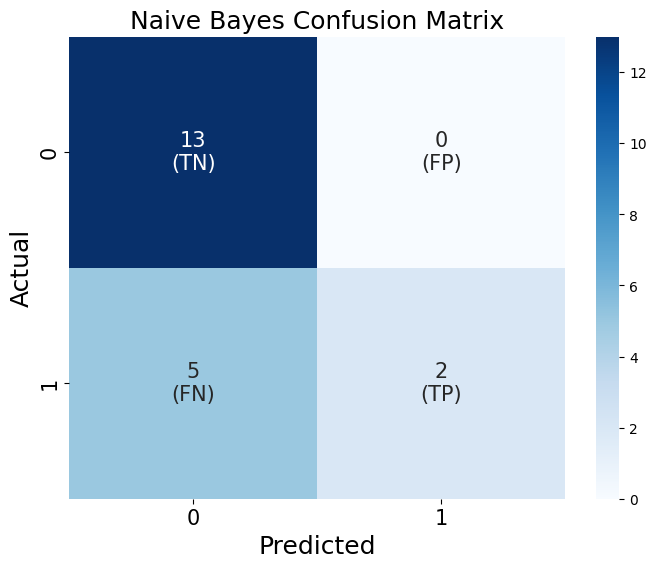

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

NB_Model = Pipeline([
    ('scaler', MinMaxScaler()),
    ('classifier', GaussianNB())
])

NB_cross_scores = cross_val_score(NB_Model, X_train, y_train, cv=5)
print(f'NB Model Cross-validation average score: {NB_cross_scores.mean()}')

# Train the model
NB_Model.fit(X_train, y_train)

# Predict on the test set
y_pred = NB_Model.predict(X_test)
y_pred_proba = NB_Model.predict_proba(X_test)[:, 1]

# Evaluation metrics
NB_accuracy = accuracy_score(y_test, y_pred)
NB_precision = precision_score(y_test, y_pred)
NB_recall = recall_score(y_test, y_pred)
NB_f1 = f1_score(y_test, y_pred)
NB_roc_auc = roc_auc_score(y_test, y_pred_proba)
NB_conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {NB_accuracy}')
print(f'Precision: {NB_precision}')
print(f'Recall: {NB_recall}')
print(f'F1 Score: {NB_f1}')
print(f'ROC-AUC Score: {NB_roc_auc}')
print(f'Confusion Matrix:\n{NB_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{NB_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(NB_conf_matrix.shape[1])] 
                              for i in range(NB_conf_matrix.shape[0])])

value, counts = np.unique(y_test, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(NB_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Naive Bayes Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

## Support Vector Machine

SVM Model Cross-validation average score: 0.7232142857142858
Accuracy: 0.65
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC-AUC Score: 0.6813186813186812
Confusion Matrix:
[[13  0]
 [ 7  0]]


c:\Users\sp2sh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


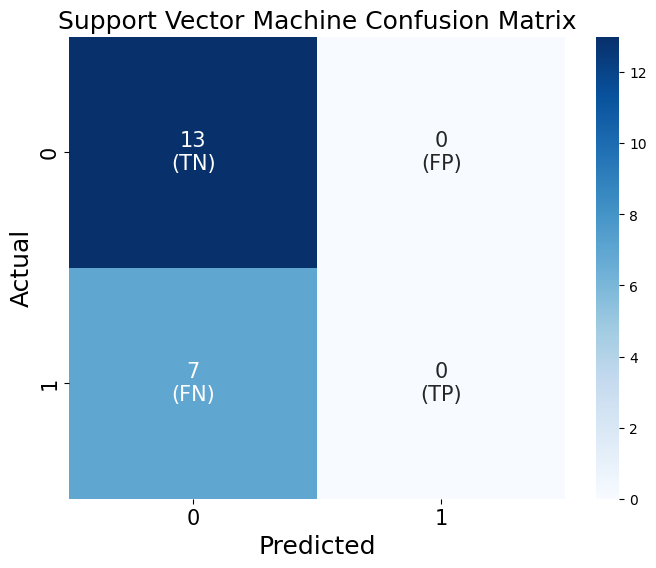

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

SVM_Model = Pipeline([
    ('scaler', MinMaxScaler()),
    ('classifier', SVC(probability=True))
])

SVM_cross_scores = cross_val_score(SVM_Model, X_train, y_train, cv=10)
print(f'SVM Model Cross-validation average score: {SVM_cross_scores.mean()}')

# Train the model
SVM_Model.fit(X_train, y_train)

# Predict on the test set
y_pred = SVM_Model.predict(X_test)
y_pred_proba = SVM_Model.predict_proba(X_test)[:, 1]

# Evaluation metrics
SVM_accuracy = accuracy_score(y_test, y_pred)
SVM_precision = precision_score(y_test, y_pred)
SVM_recall = recall_score(y_test, y_pred)
SVM_f1 = f1_score(y_test, y_pred)
SVM_roc_auc = roc_auc_score(y_test, y_pred_proba)
SVM_conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {SVM_accuracy}')
print(f'Precision: {SVM_precision}')
print(f'Recall: {SVM_recall}')
print(f'F1 Score: {SVM_f1}')
print(f'ROC-AUC Score: {SVM_roc_auc}')
print(f'Confusion Matrix:\n{SVM_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{SVM_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(SVM_conf_matrix.shape[1])] 
                              for i in range(SVM_conf_matrix.shape[0])])

value, counts = np.unique(y_test, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(SVM_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Support Vector Machine Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

## Hyperparameter Tuning

In [8]:
print('Parameters currently in use:\n')
print(RF_Model.get_params())

Parameters currently in use:

{'memory': None, 'steps': [('scaler', MinMaxScaler()), ('classifier', RandomForestClassifier())], 'transform_input': None, 'verbose': False, 'scaler': MinMaxScaler(), 'classifier': RandomForestClassifier(), 'scaler__clip': False, 'scaler__copy': True, 'scaler__feature_range': (0, 1), 'classifier__bootstrap': True, 'classifier__ccp_alpha': 0.0, 'classifier__class_weight': None, 'classifier__criterion': 'gini', 'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__max_leaf_nodes': None, 'classifier__max_samples': None, 'classifier__min_impurity_decrease': 0.0, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__min_weight_fraction_leaf': 0.0, 'classifier__monotonic_cst': None, 'classifier__n_estimators': 100, 'classifier__n_jobs': None, 'classifier__oob_score': False, 'classifier__random_state': None, 'classifier__verbose': 0, 'classifier__warm_start': False}


# Breast Cancer Gene Subset